<a href="https://colab.research.google.com/github/KathituCodes/Dirty-Cafe-Data-Cleaning-and-EDA-with-Insights/blob/main/Dirty_Cafe_Sales_Data_Cleaning_and_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dirty Cafe Sales Dataset**

## **Overview**

The objective of this analysis is to perform a comprehensive Data Wrangling and Exploratory Data Analysis (EDA) process. This involves standardizing missing values, imputing lost financial data using unit-economics logic (Total = Price * Qty), and removing statistical outliers. The final goal is to transform this 'dirty' raw file into a pristine, analysis-ready dataset to visualize sales trends and customer behavior."

# **1. Load the csv file into the Pandas dataframe**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# load the data
df = pd.read_csv('/content/dirty_cafe_sales.csv.xls')

df.head(20)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


# **2. Explore the data**

Before cleaning, we must understand the "dirtiness" of the data. We look at data types, summary statistics, and unique values to spot anomalies.

In [ ]:
# Lets display our data info
print(f"Dataset Shape: {df.shape}")

print('\n-----------------------------------------\n')

df.info()

Dataset Shape: (10000, 8)

-----------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [ ]:
""""
- The initial inspection of the dataset reveals a structure of 10,000 rows and 8 columns.
- All columns are currently object (strings). Numerical columns like Quantity, Price per unit and Total Spent should be integers or floats. The Transaction Date should be datetime. So they need to be changed to their correct formats
- The dataset was heavily comprised of object data types, which indicates a mix of strings and numbers due to placeholders like "ERROR" and "UNKNOWN" obersved from loading the head and tail of theb dataset.
- Data Types: All columns were read as objects, preventing immediate statistical analysis.
- we can also observe alot of data is missing too.
"""

'"\n- The initial inspection of the dataset reveals a structure of 10,000 rows and 8 columns.\n- All columns are currently object (strings). Numerical columns like Quantity, Price per unit and Total Spent should be integers or floats. The Transaction Date should be datetime. So they need to be changed to their correct formats\n- The dataset was heavily comprised of object data types, which indicates a mix of strings and numbers due to placeholders like "ERROR" and "UNKNOWN" obersved from loading the head and tail of theb dataset.\n- Data Types: All columns were read as objects, preventing immediate statistical analysis.\n- we can also observe alot of data is missing too.\n'

In [ ]:
# Check for the unique values in all object columns to spot the freuqency of "Error" & "unknown" and Nan in each column
for col in df.select_dtypes(include=['object']).columns:
  print(f"unique values in column'{col}'")
  print(df[col].unique())
  print()

unique values in column'Transaction ID'
['TXN_1961373' 'TXN_4977031' 'TXN_4271903' ... 'TXN_5255387' 'TXN_7695629'
 'TXN_6170729']

unique values in column'Item'
['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'UNKNOWN' 'Sandwich' nan
 'ERROR' 'Juice' 'Tea']

unique values in column'Quantity'
['2' '4' '5' '3' '1' 'ERROR' 'UNKNOWN' nan]

unique values in column'Price Per Unit'
['2.0' '3.0' '1.0' '5.0' '4.0' '1.5' nan 'ERROR' 'UNKNOWN']

unique values in column'Total Spent'
['4.0' '12.0' 'ERROR' '10.0' '20.0' '9.0' '16.0' '15.0' '25.0' '8.0' '5.0'
 '3.0' '6.0' nan 'UNKNOWN' '2.0' '1.0' '7.5' '4.5' '1.5']

unique values in column'Payment Method'
['Credit Card' 'Cash' 'UNKNOWN' 'Digital Wallet' 'ERROR' nan]

unique values in column'Location'
['Takeaway' 'In-store' 'UNKNOWN' nan 'ERROR']

unique values in column'Transaction Date'
['2023-09-08' '2023-05-16' '2023-07-19' '2023-04-27' '2023-06-11'
 '2023-03-31' '2023-10-06' '2023-10-28' '2023-07-28' '2023-12-31'
 '2023-11-07' 'ERROR' '2023-05-03'

# **3. Data Cleaning**

## **Pandas Profiling Report**

In [ ]:
!pip install ydata_profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 4.0 MB/s eta 0:00:00


In [ ]:
from ydata_profiling import ProfileReport
import pandas as pd
df = pd.read_csv('/content/dirty_cafe_sales.csv.xls')
profile =ProfileReport(df, title='EDA Report', explorative=True)
profile.to_file('dirty_cafe_sales.csv.xls Report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:01<00:00,  6.27it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## **Standardizing Missing Values**

- So I opted to standardize the data cause it transforms the messy data from various messy formats into a single, uniform, and consistent format. I want my data to "speak the same language" so I can accurately analyze and compare it against each other.

- This process gets rid of the "UNKNOWN" & "ERROR" values and replaces them with nan values

In [ ]:
# Lets replace placeholders with NaN for standardization
df_clean = df.replace({'ERROR': np.nan, 'UNKNOWN': np.nan})

# Verify the changes made and check for missing values after standardization
print(f"missing values per column after standardzation:\n{df_clean.isnull().sum()}")

missing values per column after standardzation:
Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64


In [ ]:
df_clean.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,NaN,3,3.0,9.0,NaN,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,NaN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [ ]:
# Check for the unique values in all object columns to confirm the replacement of UNKONWN and ERROR with NaN
for col in df_clean.select_dtypes(include=['object']).columns:
  print(f"unique values in column'{col}'")
  print(df_clean[col].unique())
  print()

unique values in column'Transaction ID'
['TXN_1961373' 'TXN_4977031' 'TXN_4271903' ... 'TXN_5255387' 'TXN_7695629'
 'TXN_6170729']

unique values in column'Item'
['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' nan 'Sandwich' 'Juice' 'Tea']

unique values in column'Quantity'
['2' '4' '5' '3' '1' nan]

unique values in column'Price Per Unit'
['2.0' '3.0' '1.0' '5.0' '4.0' '1.5' nan]

unique values in column'Total Spent'
['4.0' '12.0' nan '10.0' '20.0' '9.0' '16.0' '15.0' '25.0' '8.0' '5.0'
 '3.0' '6.0' '2.0' '1.0' '7.5' '4.5' '1.5']

unique values in column'Payment Method'
['Credit Card' 'Cash' nan 'Digital Wallet']

unique values in column'Location'
['Takeaway' 'In-store' nan]

unique values in column'Transaction Date'
['2023-09-08' '2023-05-16' '2023-07-19' '2023-04-27' '2023-06-11'
 '2023-03-31' '2023-10-06' '2023-10-28' '2023-07-28' '2023-12-31'
 '2023-11-07' nan '2023-05-03' '2023-06-01' '2023-03-21' '2023-11-15'
 '2023-06-10' '2023-02-24' '2023-03-25' '2023-01-15' '2023-04-04'
 '2023-

## **Data type Conversion**

After handling the "text" errors from the numerical columns, I decided to handle the data types and convert the numerical datatypes and trasaction Date into datetime. Data types dictate rules of engagement. By converting them, you telling Python: "Treat these columns as quantities and timelines, not just text labels.

- for example I observed that Without this conversion, you can not calculate the total revenue, average order value, or verify if Total = Qty * Price.

In [ ]:
# convert numerical columns to the correct data types
new_col = ["Quantity", "Price Per Unit", "Total Spent"]
for datatype in new_col:
  df_clean[datatype] = pd.to_numeric(df_clean[datatype], errors='coerce')
# convert the date column into datetime stamp
df_clean['Transaction Date'] = pd.to_datetime(df_clean['Transaction Date'],errors='coerce' )

# check the new data types
df_clean.dtypes

,0
Transaction ID,object
Item,object
Quantity,float64
Price Per Unit,float64
Total Spent,float64
Payment Method,object
Location,object
Transaction Date,datetime64[ns]


In [ ]:
""""
In Python—specifically when using the Pandas library—errors='coerce' is a powerful little argument used during data conversion. It tells Python:
"If you encounter a value that can't be converted, don't crash; just turn it into a 'Not a Number' (NaN) value."

You’ll most commonly see this used with pd.to_numeric() or pd.to_datetime().

Why Use It?
By default, Pandas is strict. If you try to turn a list of strings into numbers and one of those strings is "Apple," Pandas will throw a ValueError and stop everything.

Setting errors='coerce' allows the process to finish by replacing the problematic "Apple" with NaN (null).
""""

SyntaxError: unterminated string literal (detected at line 12) (376742500.py, line 12)

## **Handling Missing Values**


In [ ]:
# Check the number of missing values in each column first
print(f"missing values per column:\n{df_clean.isnull().sum()}")

missing values per column:
Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64


In [ ]:
# Items have a fixed price as observed so I started by first find out their fixed prices
# show each item and its price per unit

df_clean.groupby('Item')['Price Per Unit'].mean()

,Price Per Unit
Item,
Cake,3.0
Coffee,2.0
Cookie,1.0
Juice,3.0
Salad,5.0
Sandwich,4.0
Smoothie,4.0
Tea,1.5


## **Imputing missing values**

In [ ]:
# Imputing missing Values (filling in the blanks)
# Recover price per unit using Item
# Calculate the most common price (Mode) for each Item

item_price_map = df_clean.groupby('Item')['Price Per Unit'].apply(lambda x: x.mode()[0] if not x.mode().empty else np.nan).to_dict()
print("Item Price Map:", item_price_map)

Item Price Map: {'Cake': 3.0, 'Coffee': 2.0, 'Cookie': 1.0, 'Juice': 3.0, 'Salad': 5.0, 'Sandwich': 4.0, 'Smoothie': 4.0, 'Tea': 1.5}


In [ ]:
# Fill missing Price based on Item
df_clean['Price Per Unit'] = df_clean.apply(
    lambda row: item_price_map.get(row['Item'], row['Price Per Unit']) if pd.isna(row['Price Per Unit']) else row['Price Per Unit'],
    axis=1)
print(f"Remaining missing values:\n{df_clean.isnull().sum()}")

Remaining missing values:
Transaction ID         0
Item                 969
Quantity             479
Price Per Unit        54
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64


In [ ]:
# Recover 'Item' using 'Price Per Unit'
# If an Item is missing but the Price is $2.00, and only Coffee costs $2.00, we know it's Coffee.
# Create a reverse map (Price -> Item) only for unique prices
# Initialize an empty dictionary to store our "Price -> Item"
price_item_map = {}

# Loop through every unique price found in the dataset (ignoring NaNs)
# We want to check if $2.00 belongs to ONLY one item or multiple items
for price in df_clean['Price Per Unit'].dropna().unique():

   # For the current price, find all unique 'Item' names associated with it
    # We filter the dataframe for that price, grab the 'Item' column, drop NaNs, and get unique names
    items_at_this_price = df_clean[df_clean['Price Per Unit'] == price]['Item'].dropna().unique()

    # The aim to to check if this price belong to exactly ONE item type?
    # If len is 1, it means $2.00 is EXCLUSIVELY for "Coffee". Safe to map.
    # If len is > 1, it means $3.00 could be "Cake" OR "Juice". UNSAFE to map (we skip it).
    # Builds a Safety List: It figures out which prices are "unique identifiers." (e.g., If $5.00 always means Salad, we can trust it. If $3.00 means Cake or Juice, we ignore it).
    # Fills the Blanks: It scans the dataset. Wherever it sees a missing item name, it checks the price. If the price is on the "Safety List" (e.g., $5.00), it fills in the name ("Salad").
    if len(items_at_this_price) == 1:
        # Save this rule in our dictionary
        price_item_map[price] = items_at_this_price[0]

# Use .apply() to go through every row in the dataframe to fill missing Items
df_clean['Item'] = df_clean.apply(
    lambda row:
        price_item_map.get(row['Price Per Unit'], row['Item'])# IF the Item is missing (pd.isna checks for NaN)...# .get() looks up the price; if not found, it returns the existing (NaN) Item.
        if pd.isna(row['Item'])# THEN try to find the Item name using the price_item_map dictionary.
        else row['Item'],      # ELSE (if Item is not missing), just keep the existing Item name.
    axis=1  # axis=1 means "apply this logic row by row" (horizontally)
)

print(f"Remaining missing values:\n{df_clean.isnull().sum()}")


Remaining missing values:
Transaction ID         0
Item                 501
Quantity             479
Price Per Unit        54
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64


In [ ]:
"""
What it simply means is:

**"Look at this row. Is the Item name missing?**

If No: Keep it as is.

If Yes: Check the Price. Does this Price appear in our 'Safe List' (the map)?

If Yes: Replace the missing name with the Item from the map (e.g., change NaN to 'Salad').

If No: Leave it as NaN."
"""

In [ ]:
# *Calculate missing financials*

# If Total is missing: I used Quantity * Price to find the total spent
df_clean['Total Spent'] = df_clean['Total Spent'].fillna(df_clean['Quantity'] * df_clean['Price Per Unit'])

# If Quantity is missing: I used Total / Price to find the quantity
df_clean['Quantity'] = df_clean['Quantity'].fillna(df_clean['Total Spent'] / df_clean['Price Per Unit'])

print(f"Remaining missing values:\n{df_clean.isnull().sum()}")


Remaining missing values:
Transaction ID         0
Item                 501
Quantity              23
Price Per Unit        54
Total Spent           23
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64


In [ ]:
""""
Random distribution-based imputation is actually the better suggestion over mode imputation for your specific case. Here's why:

The problem with Mode Imputation is that it fills all 3,178 missing Payment Method values and all 3,961 missing
Location values with a single category (the most frequent one). If "Cash" is the mode for Payment Method, suddenly ~32% of
your dataset gets forced into "Cash." This artificially inflates one category and distorts any downstream analysis — like if you later ask "what percentage of
customers pay with Cash vs. Credit Card vs. Digital Wallet?", the answer would be skewed.

Random Distribution-Based Imputation solves this by sampling from the existing proportions. For example, if the non-missing Payment Method data shows 40% Cash,
35% Credit Card, and 25% Digital Wallet, the missing values get filled following that same 40/35/25 split. The overall distribution stays intact.

""""


In [ ]:
# Random Distribution Imputation for Payment Method
payment_dist = df_clean['Payment Method'].dropna().value_counts(normalize=True)
df_clean.loc[df_clean['Payment Method'].isna(), 'Payment Method'] = np.random.choice(
    payment_dist.index,
    size=df_clean['Payment Method'].isna().sum(),
    p=payment_dist.values
)
# Random Distribution Imputation for Location
location_dist = df_clean['Location'].dropna().value_counts(normalize=True)
df_clean.loc[df_clean['Location'].isna(), 'Location'] = np.random.choice(
    location_dist.index,
    size=df_clean['Location'].isna().sum(),
    p=location_dist.values
)

print(f"Remaining missing values:\n{df_clean.isnull().sum()}")

Remaining missing values:
Transaction ID        0
Item                501
Quantity             23
Price Per Unit       54
Total Spent          23
Payment Method        0
Location              0
Transaction Date    460
dtype: int64


## **Handling Unrecoverable Data & Categoricals**

Some rows may still have missing dates or multiple missing financial fields that logic couldn't fix. so we can find the best method to deal with them


In [ ]:
""""
Filling with "Unknown" seems like a safe middle ground, but the impact depends heavily on which column you're doing it to. Let me break it down:

**For Item (501 missing, 5.0%) — "Unknown" is acceptable but has trade-offs**:
Setting missing Items to "Unknown" means you preserve the rows (keeping their Quantity, Price, Total Spent data intact). However, "Unknown" becomes its own category.
When you later do analysis like "which item sells the most?" or "what's the revenue breakdown by product?", you'll have an "Unknown" bar sitting in your charts.
It won't corrupt the other items' numbers, but it does create a phantom category that doesn't represent a real product. If you're okay with acknowledging "5% of sales
had unidentifiable items" in your analysis, this works fine.

**For Transaction Date (460 missing, 4.6%) — "Unknown" is problematic**:
This column was converted to datetime format. Setting it to "Unknown" would either force it back to a string (breaking your datetime type) or throw an error.
Even if you kept it as NaT (the datetime equivalent of NaN), any time-series analysis like "sales trend by month" or "busiest day of the week" would simply
exclude those rows anyway. So labeling them "Unknown" doesn't gain you anything — they'd behave the same as if they were dropped from time-based analysis.

**For Quantity (23), Price Per Unit (54), and Total Spent (23) — "Unknown" is damaging**
These are numerical columns. Setting them to "Unknown" converts the entire column from float/int back to object (string) type.
This immediately breaks every numerical operation: you can't calculate total revenue, average order value, sum of quantities, or any statistical analysis.
Even a simple `df_clean['Total Spent'].sum()` would fail. At a combined ~0.7% of data, you'd be sacrificing the analytical power of entire columns to save a
handful of rows.

**My recommendation by column:**
For **Item**, filling with "Unknown" is a reasonable choice if you want to preserve row count. Just be transparent about it in your analysis.
For the **numerical columns** (Quantity, Price Per Unit, Total Spent), drop those rows — they're tiny in number and "Unknown" would break your calculations.
For **Transaction Date**, drop those rows as well — "Unknown" either breaks the datetime type or offers no benefit over simply excluding them.

So a practical hybrid approach would be:

```
# Item: fill with 'Unknown' to preserve rows
df_clean['Item'] = df_clean['Item'].fillna('Unknown')

# Numerical columns + Date: drop rows where these are missing
df_clean.dropna(subset=['Quantity', 'Price Per Unit', 'Total Spent', 'Transaction Date'], inplace=True)
```

This keeps your dataset as large as possible while protecting the integrity of your numerical and time-series analysis.

""""

In [ ]:
# Item: fill with 'Unknown' to preserve rows
df_clean['Item'] = df_clean['Item'].fillna('Unknown')

# Numerical columns + Date: drop rows where these are missing
df_clean.dropna(subset=['Quantity', 'Price Per Unit', 'Total Spent', 'Transaction Date'], inplace=True)

print(f"Remaining missing values:\n{df_clean.isnull().sum()}")

Remaining missing values:
Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64


In [ ]:
# Check final count
print(f"Data shape after dropping unrecoverable rows: {df_clean.shape}")

Data shape after dropping unrecoverable rows: (9469, 8)


In [ ]:
# Save the clean dataset
df_clean.to_csv('cafe_sales_clean.csv', index=False)

In [ ]:

df_clean = pd.read_csv('/content/cafe_sales_clean.csv')
profile =ProfileReport(df_clean, title='EDA Report', explorative=True)
profile.to_file('Cleaned_cafe_sales.csv.xls Report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 15.35it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## **Handle Duplicates**

In [ ]:
# Next lets check for duplicates in our dataset
duplicate_rows = df_clean[df_clean.duplicated()]
print(f"Number of duplicate rows: {len(duplicate_rows)}")

Number of duplicate rows: 0


## **Detecting Outliers**

Now we need to ensure the math adds up (Qantity * Price == Total Spent).

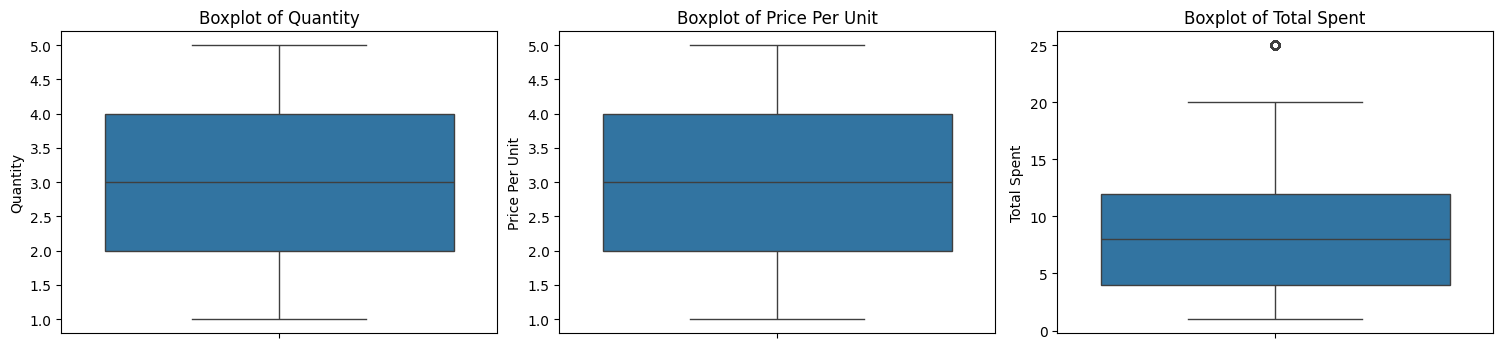

In [ ]:
# Visualize outliers using boxplots
numerical_col = ['Quantity','Price Per Unit','Total Spent']
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_col, 1): # # Loop through each numerical column name; 'enumerate' gives us both the index (i) starting at 1 and the column name (col)
    plt.subplot(3, 3, i)  # # Create a grid of plots with 3 rows and 3 columns, and select the 'i-th' empty slot for the current plot
    sns.boxplot(y=df_clean[col])  # Draw a boxplot for the current column's data to visually check for outliers and data distribution
    plt.title(f'Boxplot of {col}')
plt.tight_layout()  # # Automatically adjust the padding between subplots so that titles and labels don't overlap
plt.show()

In [ ]:
# Lets check for outliers using IQR in the numerical columns
# What IQR does is it filters the dataset to find the rows that fall outside the fences of Q3 - Q1
# Defines the specific columns you want to check (Quantity, Price,Total Spent)
numerical_col = ['Quantity','Price Per Unit','Total Spent']
for col in numerical_col:
  Q1 = df_clean[col].quantile(0.25)
  Q3 = df_clean[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
  print(f"number of outliers in {col}: {len(outliers)}")

number of outliers in Quantity: 0
number of outliers in Price Per Unit: 0
number of outliers in Total Spent: 259


In [ ]:
# Lets check for outliers using IQR in the numerical columns aftern handling outliers
# ── Step 1: Re-run IQR check on Total Spent AFTER the math correction ──────────
# Now that Total Spent = Quantity * Price for every row, any remaining
# IQR outlier is a genuinely extreme-but-real transaction (e.g. 5 x Salad = $25).
# We investigate before deciding what to do with them.

col = 'Total Spent'
Q1 = df_clean[col].quantile(0.25)
Q3 = df_clean[col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
print(f"IQR bounds  →  lower: {lower_bound:.2f}  |  upper: {upper_bound:.2f}")
print(f"Outliers remaining after math correction: {outlier_mask.sum()}")
print()

# ── Step 2: Inspect the outliers ───────────────────────────────────────────────
# Look at which Item / Quantity combinations are causing the high totals.
# In a café with menu prices of $1–$5 and quantities of 1–5,
# the maximum possible legitimate Total Spent is 5 * $5 = $25.
print("Distribution of outlier rows:")
print(df_clean[outlier_mask][['Item', 'Quantity', 'Price Per Unit', 'Total Spent']]
      .sort_values('Total Spent', ascending=False)
      .head(20))
print()
print(f"Max possible legitimate total (5 × $5): $25.00")
print(f"Actual max Total Spent in outliers: ${df_clean.loc[outlier_mask, col].max():.2f}")

# ── Step 3: Validate — are outliers within the real business range? ─────────────
# Since every Total Spent is now derived from Quantity * Price, and both those
# columns were already cleaned, the outliers are mathematically correct values.
# Any total > $25 would be impossible given the menu, so we cap at $25 as a
# safety net. Totals that are simply "high but valid" (e.g. $20, $25) are kept.

MAX_POSSIBLE_TOTAL = 5 * 5.0  # max qty * max price = $25

impossible_mask = df_clean[col] > MAX_POSSIBLE_TOTAL
print(f"\nRows with Total Spent > ${MAX_POSSIBLE_TOTAL:.2f} (physically impossible): {impossible_mask.sum()}")

if impossible_mask.sum() > 0:
    print("These rows are being capped at the maximum possible value.")
    df_clean.loc[impossible_mask, col] = MAX_POSSIBLE_TOTAL
else:
    print("No impossible values found — all outliers are high-but-legitimate transactions.")
    print("Decision: RETAIN these rows. They represent real high-value orders (e.g. 5x Salad = $25).")

# ── Step 4: Final confirmation ──────────────────────────────────────────────────
Q1_new = df_clean[col].quantile(0.25)
Q3_new = df_clean[col].quantile(0.75)
IQR_new = Q3_new - Q1_new
final_outliers = ((df_clean[col] < Q1_new - 1.5 * IQR_new) |
                  (df_clean[col] > Q3_new + 1.5 * IQR_new)).sum()

print(f"\nFinal IQR outlier count in '{col}': {final_outliers}")
print(f"Final dataset shape: {df_clean.shape}")
print("\nTotal Spent — summary statistics after handling:")
print(df_clean[col].describe().round(2))

IQR bounds  →  lower: -8.00  |  upper: 24.00
Outliers remaining after math correction: 259

Distribution of outlier rows:
       Item  Quantity  Price Per Unit  Total Spent
9443  Salad       5.0             5.0         25.0
10    Salad       5.0             5.0         25.0
48    Salad       5.0             5.0         25.0
8862  Salad       5.0             5.0         25.0
8812  Salad       5.0             5.0         25.0
8805  Salad       5.0             5.0         25.0
8796  Salad       5.0             5.0         25.0
8697  Salad       5.0             5.0         25.0
8690  Salad       5.0             5.0         25.0
8676  Salad       5.0             5.0         25.0
8637  Salad       5.0             5.0         25.0
8609  Salad       5.0             5.0         25.0
8606  Salad       5.0             5.0         25.0
8595  Salad       5.0             5.0         25.0
8555  Salad       5.0             5.0         25.0
8501  Salad       5.0             5.0         25.0
8447  Salad

In [ ]:
# Save the clean dataset
df_clean.to_csv('cafe_sales_clean.csv', index=False)

# **4. Exploratory Data Analysis (EDA)**

In [ ]:
# Lets check the frequency of items sold in the cafe
item_counts = df_clean['Item'].value_counts()
item_counts

,count
Item,
Coffee,1234
Salad,1212
Cookie,1145
Tea,1134
Juice,1121
Cake,1081
Sandwich,1071
Smoothie,1046
Unknown,425


## **Sales Overview**

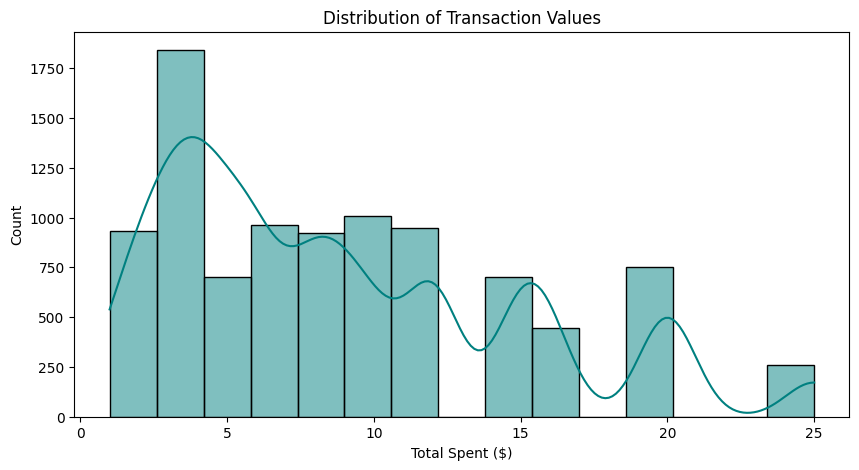

In [ ]:
# Distribution of Total Spent
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['Total Spent'], bins=15, kde=True, color='teal')
plt.title('Distribution of Transaction Values')
plt.xlabel('Total Spent ($)')
plt.show()

## **Best Selling Items**

Which items generated the most revenue?

/tmp/ipykernel_1023/305046763.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=item_sales, x='Total Spent', y='Item', palette='viridis')


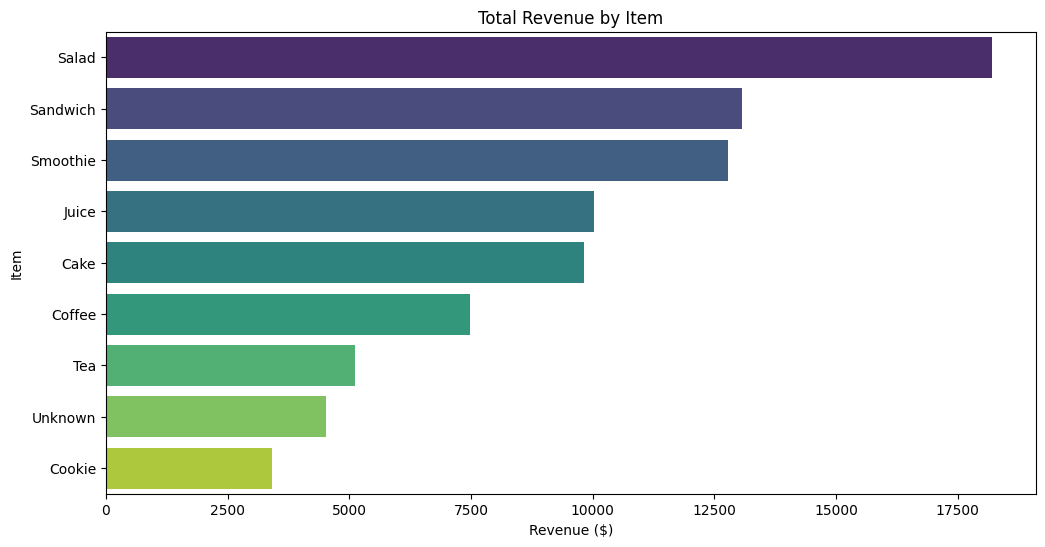

In [ ]:
# Total Sales by Item
item_sales = df_clean.groupby('Item')['Total Spent'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=item_sales, x='Total Spent', y='Item', palette='viridis')
plt.title('Total Revenue by Item')
plt.xlabel('Revenue ($)')
plt.show()

Salads and Sandwiches are the top earners for the cafe. Even though Coffee shows the highest frequency of items sold, the higher unit priced food items drive more total revenue.



## **Sales Trends Over Time**

Is the business growing?

In [ ]:
import plotly.express as px

# Daily Sales Trend
daily_sales = df_clean.groupby('Transaction Date')['Total Spent'].sum().reset_index()

# Using Plotly for an interactive chart
fig = px.line(daily_sales, x='Transaction Date', y='Total Spent', title='Daily Sales Trend')
fig.show()

## **Payment Method Analysis**

what are the most common modes of payments customers use?

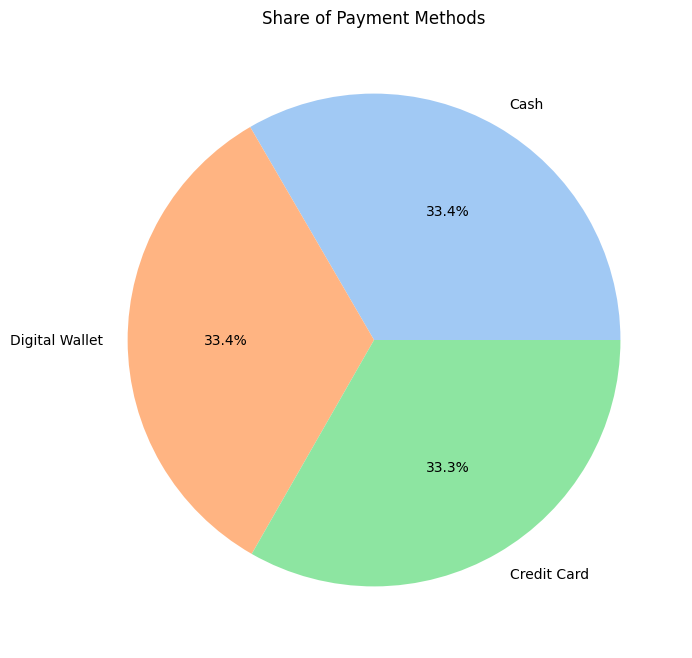

In [ ]:
# Payment Method usage
payment_counts = df_clean['Payment Method'].value_counts() # counts how many times each payment type appears

plt.figure(figsize=(8, 8))   # Creates an 8x8 inch square for the chart to fit in
plt.pie(payment_counts, # The numbers to plot
        labels=payment_counts.index,  # The names for each payment method(Cash, Credit Card)
        autopct='%1.1f%%',    # Adds the percentage text inside the slices
        colors=sns.color_palette('pastel'))  # Makes the colors soft/pastel

plt.title('Share of Payment Methods') # Plot title label
plt.show() # Displays the plot

## **Revenue by Item and Payment Method**

How much money was made from items paid via Cash versus Credit Card and Digital wallet?

Lets compare each item and the method of payment used for each.

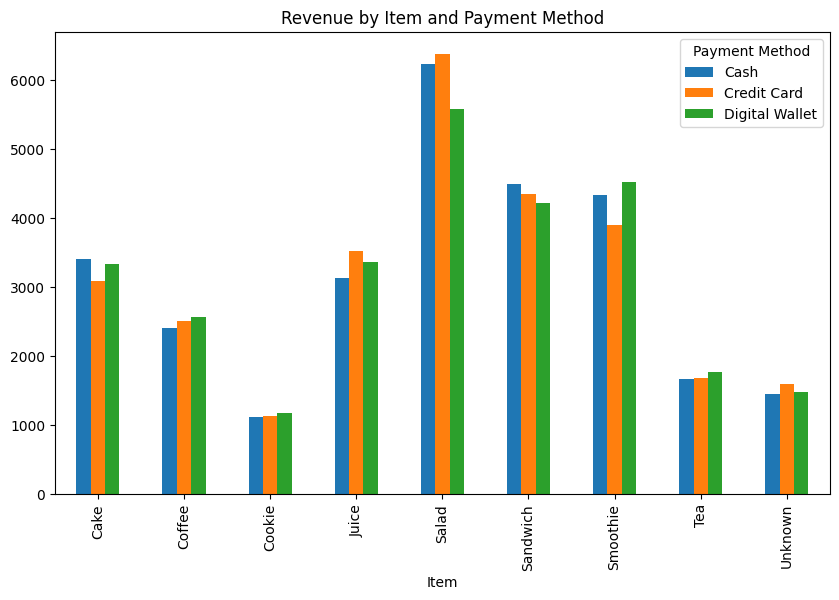

In [ ]:
payment = df_clean.pivot_table(
    values='Total Spent',  # # The column we want to calculate (Money)
    index='Item',
    columns='Payment Method',  # the payment method used
    aggfunc='sum'   # The math opertaion (sum of all items)
)

payment.plot(kind='bar', figsize=(10,6))   # Bar plot and plot size
plt.title('Revenue by Item and Payment Method')  # plot title
plt.show()  # display the plot

## **Revenue by Item and Location**

Do people prefer to eat this item inside the cafe or take it away?

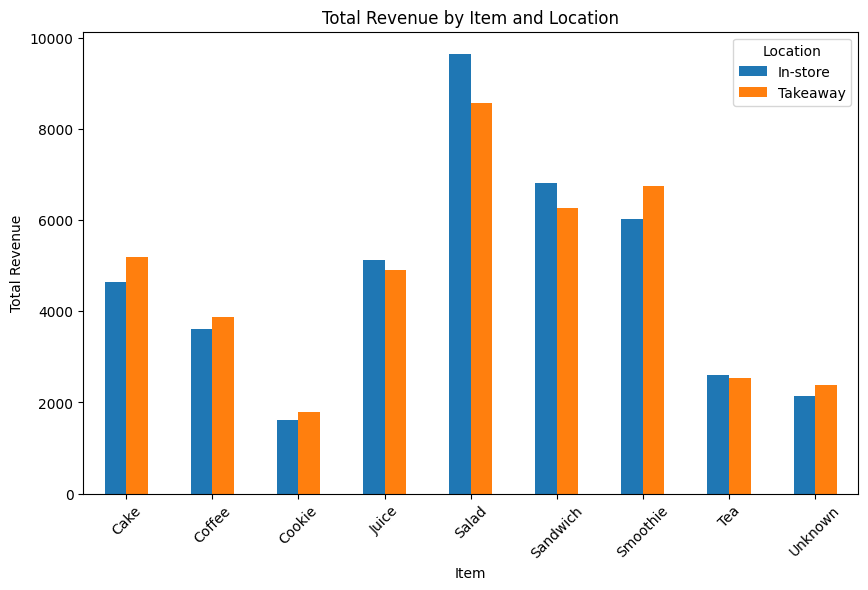

In [ ]:
Location = df_clean.pivot_table(
    values='Total Spent',
    index='Item',
    columns='Location',
    aggfunc='sum'    #  # The math opertaion (sum of all items)
)

Location.plot(kind='bar', figsize=(10,6))   # bar plot

plt.title('Total Revenue by Item and Location')
plt.xlabel('Item')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.legend(title='Location')
plt.show()

# **Conclusion**

* **Data Quality Issues:** I found that a good chunk of the dataset was compromised by missing values in key fields like `Location` and `Payment Method`. This indicates a significant gap in data collection at the Point of Sale.

* From a business perspecive I observed that the business is overwhelmingly "Grab-and-Go," with a large margin of revenue coming from Takeaway orders**.

* **Payment Preferences:** I noticed a strong preference for speed, as **Digital Wallets accounts significantly outperforming Cash and Credit Cards.

* **Sales Trend:** I saw that the daily sales trend is incredibly **stable but flat**, showing consistent demand without any significant growth or seasonality.

**My Recommendations:**


1. **Optimize for Speed:** Given the dominance of Takeaway and Digital Payments.

2. **Drive Growth:** To break the flat sales trend, I recommend introducing bundled deals to increase the average transaction value.